# Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

## Problem Statement

In the fast-paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness. Our goal is to use data-driven insights to maximise revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

## Objective

This project's main goal is to run an A/B test to examine the relationship between the total fare and the method of payment. We use Python hypothesis testing and descriptive statistics to extract useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.

## Research Question

Is there a relationship between total fare amount and payment type, and can we nudge customers towards payment methods that generate higher revenue for drivers, without negatively impacting customer experience?

## Importing Libraries

# Step 1: Import libraries

In [1]:
# pandas for data handling, matplotlib/seaborn for plots, scipy for stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')


## Step 2 — Loading the Data
We load `Trip_data.csv` into a DataFrame called `df`. Think of it as opening a giant Excel sheet with 6.4M rows.


In [2]:
# Step 2: Load the raw trip data (6.4M NYC taxi trips, Jan 2020)
df = pd.read_csv('Trip_data.csv')


## Step 3 — Exploratory Data Analysis (EDA)
**Goal:** Understand shape, types, and sanity of data *before* cleaning. We ask: How big? What types? Any obvious errors?


In [3]:
# First look: 5 sample trips to understand columns
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


**What you see:** 5 example trips. Key cols: `passenger_count`, `trip_distance`, `payment_type (1/2)`, `fare_amount`, plus datetimes and surcharges. Last rows already hint at missing values (NaN).


In [4]:
# Dataset size: rows x columns
df.shape


(6405008, 18)

In [5]:
df.dtypes

VendorID                 float64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag           str
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

**Why it matters:** `tpep_pickup_datetime` is text (`object`), not datetime. We must convert it to subtract times. `payment_type`/`passenger_count` are floats due to NaNs — we will fix to int later.


In [6]:

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])


**What we did:** Converted both timestamp columns with `pd.to_datetime`. Now Python understands them as real dates.


### Feature Engineering: `time_duration`
Trip length in **minutes** is more useful than two timestamps. Formula: `(drop-off − pickup).total_seconds()/60`.


In [7]:
# Feature engineering: trip length in minutes = drop-off minus pickup
df['time_duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['time_duration'] = df['time_duration'].dt.total_seconds()/60


In [8]:
# Preview the new time_duration column (in minutes)
df['time_duration']


0           4.800000
1           7.416667
2           6.183333
3           4.850000
4           2.300000
             ...    
6405003    31.000000
6405004    76.000000
6405005    27.833333
6405006    22.650000
6405007    22.000000
Name: time_duration, Length: 6405008, dtype: float64

**Check:** Values like 4.8, 7.4 mins look realistic. Later we will drop negatives/zeros (clock errors).


### Focus the table
We keep only 5 columns needed for the payment-vs-fare question and drop the rest (vendor, zones, tips, tolls, etc.) to keep analysis fast and clear.


In [9]:
df = df[['passenger_count','trip_distance','payment_type','fare_amount','time_duration']]

In [10]:
df

,passenger_count,trip_distance,payment_type,fare_amount,time_duration
0,1.0,1.20,1.0,6.00,4.800000
1,1.0,1.20,1.0,7.00,7.416667
2,1.0,0.60,1.0,6.00,6.183333
3,1.0,0.80,1.0,5.50,4.850000
4,1.0,0.00,2.0,3.50,2.300000
...,...,...,...,...,...
6405003,NaN,3.24,NaN,17.59,31.000000
6405004,NaN,22.13,NaN,46.67,76.000000
6405005,NaN,10.51,NaN,48.85,27.833333
6405006,NaN,5.49,NaN,27.17,22.650000


**Preview:** 6.4M × 5 clean-focused table. Note `NaN` in last rows for `passenger_count`/`payment_type` — handled next.


## Step 4 — Handle Missing Values
**Why:** Missing payment or passenger data cannot be grouped. Only 65,441 rows (~1%) are affected, so dropping is safe.


In [11]:
df.isnull().sum()

passenger_count    65441
trip_distance          0
payment_type       65441
fare_amount            0
time_duration          0
dtype: int64

**Reading:** `passenger_count` 65,441 missing, `payment_type` 65,441 missing, others 0. Same rows are missing both.


In [12]:
df.dropna(inplace=True)

In [13]:
df

,passenger_count,trip_distance,payment_type,fare_amount,time_duration
0,1.0,1.20,1.0,6.0,4.800000
1,1.0,1.20,1.0,7.0,7.416667
2,1.0,0.60,1.0,6.0,6.183333
3,1.0,0.80,1.0,5.5,4.850000
4,1.0,0.00,2.0,3.5,2.300000
...,...,...,...,...,...
6339562,1.0,2.10,1.0,11.0,14.233333
6339563,1.0,2.13,1.0,13.0,19.000000
6339564,1.0,2.55,1.0,12.5,16.283333
6339565,1.0,1.61,2.0,8.5,9.633333


**After:** 6,339,567 rows remain. No NaNs left.


## Step 5 — Fix Types & Remove Duplicates
Integers are better for counts. Duplicates (identical 5-col rows) would double-count the same pattern — we found **3,331,706** of them!


In [14]:
# Convert passenger_count and payment_type to integers for clean grouping
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')


In [15]:
# Find exact duplicate trips (same 5 values)
df[df.duplicated()]


,passenger_count,trip_distance,payment_type,fare_amount,time_duration
2056,1,0.00,2,7.0,0.000000
2441,1,0.00,1,52.0,0.200000
2446,2,1.70,1,9.5,13.066667
2465,1,0.40,1,4.0,3.083333
3344,1,1.20,1,6.0,5.350000
...,...,...,...,...,...
6339558,1,1.63,2,8.0,8.800000
6339559,1,1.81,1,8.5,8.016667
6339560,1,0.98,2,6.5,6.900000
6339562,1,2.10,1,11.0,14.233333


In [16]:
# Remove duplicates to avoid double-counting the same trip pattern
df.drop_duplicates(inplace = True)


In [17]:
df

,passenger_count,trip_distance,payment_type,fare_amount,time_duration
0,1,1.20,1,6.0,4.800000
1,1,1.20,1,7.0,7.416667
2,1,0.60,1,6.0,6.183333
3,1,0.80,1,5.5,4.850000
4,1,0.00,2,3.5,2.300000
...,...,...,...,...,...
6339555,3,2.09,1,10.0,14.800000
6339561,1,4.11,1,17.5,21.500000
6339563,1,2.13,1,13.0,19.000000
6339564,1,2.55,1,12.5,16.283333


**After dedup:** 3,007,861 unique rows. Big drop, but necessary for fair averages.


## Step 6 — Filter Invalid Categories
**Passenger insight:** 58% solo (1 passenger), 19% duo. `0` passengers is impossible; `7/8/9` are ultra-rare (<0.002%) and likely errors. We keep 1–6. We also keep only payment `1/2` (Card/Cash).


In [18]:
# Distribution of passenger counts - most trips are solo (58%), check invalid 0/7/8/9
df['passenger_count'].value_counts(normalize=True)


passenger_count
1    0.581981
2    0.190350
3    0.066360
5    0.062937
6    0.039272
4    0.036046
0    0.023033
7    0.000009
9    0.000006
8    0.000006
Name: proportion, dtype: float64

In [19]:
# Keep realistic passenger counts 1-6 and payment types 1 (Card) / 2 (Cash) only
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 7)]
df = df[df['payment_type'] < 3]


### Make labels human-readable
`1 → Card`, `2 → Cash`. From now on charts say Card/Cash, not 1/2.


In [20]:
# Make payment_type human-readable: 1 -> Card, 2 -> Cash
df['payment_type'] = df['payment_type'].replace({
    1: 'Card',
    2: 'Cash'
})


## Step 7 — Remove Impossible Values
`describe()` reveals data-entry errors: distance −22 miles, fare −$500, duration −2770 mins. A taxi cannot go negative!


In [21]:
# Summary stats BEFORE removing impossible values - note negatives!
df.describe()


,passenger_count,trip_distance,fare_amount,time_duration
count,2.898158e+06,2.898158e+06,2.898158e+06,2.898158e+06
mean,1.906919e+00,4.479349e+00,1.761232e+01,2.402879e+01
std,1.427756e+00,4.867743e+00,1.495772e+01,9.293099e+01
min,1.000000e+00,-2.218000e+01,-5.000000e+02,-2.770367e+03
25%,1.000000e+00,1.470000e+00,8.500000e+00,9.716667e+00
50%,1.000000e+00,2.690000e+00,1.300000e+01,1.553333e+01
75%,2.000000e+00,5.370000e+00,2.100000e+01,2.318333e+01
max,6.000000e+00,2.628800e+02,4.265000e+03,8.525117e+03


In [22]:
# Remove impossible trips: distance, fare and duration must be > 0
df = df[df['trip_distance'] > 0] 
df = df[df['fare_amount']>0]
df = df[df['time_duration']> 0]


In [23]:
# Stats AFTER removing negatives/zeros: mins now sensible, but max still huge (outliers remain)
df.describe()


,passenger_count,trip_distance,fare_amount,time_duration
count,2.866585e+06,2.866585e+06,2.866585e+06,2.866585e+06
mean,1.913070e+00,4.523730e+00,1.747778e+01,2.405541e+01
std,1.431386e+00,4.869850e+00,1.437862e+01,9.305349e+01
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.500000e+00,8.500000e+00,9.783333e+00
50%,1.000000e+00,2.710000e+00,1.300000e+01,1.556667e+01
75%,2.000000e+00,5.410000e+00,2.050000e+01,2.313333e+01
max,6.000000e+00,2.628800e+02,4.265000e+03,8.525117e+03


## Step 8 — Remove Outliers (IQR Method)
**Simple idea:** For fare/distance/duration, find middle 50% (Q1–Q3). Anything farther than 1.5×IQR below/above is an outlier (e.g., $4265 fare, 262-mile trip). We drop those. This is standard, not deleting good data.


In [24]:
# Remove outliers with IQR rule (Q1-1.5*IQR to Q3+1.5*IQR) for fare, distance, duration
for col in ['fare_amount','trip_distance','time_duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3-q1

    lower_bound = q1-(1.5*iqr)
    upper_bound = q3 + (1.5*iqr)

    df = df[(df[col]>= lower_bound) & (df[col]<= upper_bound)]


In [25]:
# Final clean dataset: ~2,395,692 trips ready for analysis
df


,passenger_count,trip_distance,payment_type,fare_amount,time_duration
0,1,1.20,Card,6.0,4.800000
1,1,1.20,Card,7.0,7.416667
2,1,0.60,Card,6.0,6.183333
3,1,0.80,Card,5.5,4.850000
5,1,0.03,Cash,2.5,0.883333
...,...,...,...,...,...
6339550,4,2.40,Card,10.5,12.383333
6339555,3,2.09,Card,10.0,14.800000
6339561,1,4.11,Card,17.5,21.500000
6339563,1,2.13,Card,13.0,19.000000


**Final clean data: 2,395,692 trips.** This is our analysis base — large, realistic, and comparable.


## Analysis — Plot 1: Fare & Distance Distributions by Payment
**Question:** Do Card trips cluster at higher fares/longer distances than Cash? Overlapping histograms let us see shape, not just averages.


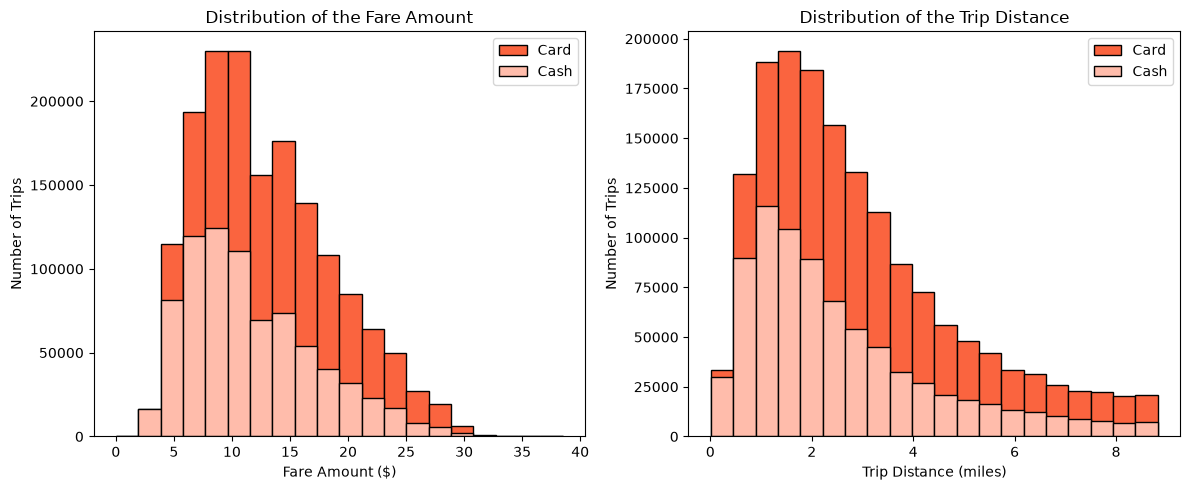

In [26]:
# Plot 1: Compare Fare and Distance distributions for Card vs Cash
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution of the Fare Amount')
plt.hist(df[df['payment_type'] == 'Card'] ['fare_amount'],histtype='barstacked',bins=20,edgecolor='k', color='#FA643F', label='Card')
plt.hist(df[df['payment_type'] == 'Cash'] ['fare_amount'],histtype='barstacked',bins=20,edgecolor='k', color='#FFBCAB', label='Cash')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Number of Trips')
plt.legend()
plt.subplot(1,2,2)
plt.title('Distribution of the Trip Distance')
plt.hist(df[df['payment_type'] == 'Card'] ['trip_distance'],histtype='barstacked',bins=20,edgecolor='k', color='#FA643F', label='Card')
plt.hist(df[df['payment_type'] == 'Cash'] ['trip_distance'],histtype='barstacked',bins=20,edgecolor='k', color='#FFBCAB', label='Cash')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Number of Trips')
plt.legend()
plt.tight_layout()


**How to read:** Orange = Card, light pink = Cash. Both peak at low fares ($5–$15) but Card has a fatter tail to $25+. Same for distance: Card trips stretch further right. → Early hint Card = higher revenue.


## Analysis — Table: Average Fare & Distance
Means tell the revenue story in one number; std shows spread.


In [27]:
# Average fare and distance by payment type (mean + std)
df.groupby('payment_type').agg({'fare_amount': ['mean', 'std'], 'trip_distance': ['mean','std']})


fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           12.921630  5.776835      2.930817  1.955602
Cash           11.634799  5.546694      2.562072  1.881217

**Key numbers:**
- **Fare:** Card **$12.92** vs Cash **$11.63** → **+$1.29 (+11%) for Card**
- **Distance:** Card **2.93 miles** vs Cash **2.56 miles** → Card trips are ~0.37 miles longer
- Spreads similar (std ~$5.6–$5.7), so difference is not just noise.
**Interpretation:** Card riders take slightly longer trips and pay more. Even $1 extra × millions of trips = large revenue.


## Analysis — Plot 2: Payment Preference
Do customers even use Card enough to matter?


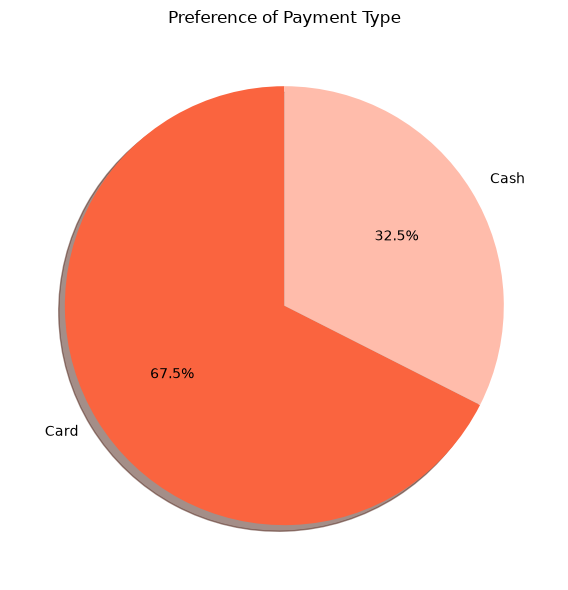

In [28]:
# Plot 2: Which payment method do customers prefer?
plt.figure(figsize=(6,6))
plt.title("Preference of Payment Type")
plt.pie(df['payment_type'].value_counts(normalize= True), labels=df['payment_type'].value_counts().index, startangle=90,
        shadow=True, autopct='%1.1f%%', colors=['#FA643F','#FFBCAB'])
plt.ylabel('')  # hide default ylabel for cleaner pie
plt.tight_layout()


**Result:** **Card 67.5% vs Cash 32.5%** — Card already dominates 2-to-1. Nudging the remaining Cash users toward Card is realistic (e.g., card reader availability, small incentive) and won't alienate most riders.


## Analysis — Plot 3: Passenger Mix by Payment
Does group size explain the fare gap? We count every (payment × passengers) combo.


In [29]:
# Count trips for each (payment_type, passenger_count) combo
passenger_count = df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns = {'passenger_count':'count'}, inplace=True)
passenger_count.reset_index(inplace = True)


In [30]:
# Convert counts to % of ALL trips so Card vs Cash are comparable
passenger_count['perc'] = (passenger_count['count']/passenger_count['count'].sum())*100


In [31]:
# Preview the breakdown table (e.g. Card+1 passenger = 37.7% of all trips)
passenger_count


,payment_type,passenger_count,count,perc
0,Card,1,904168,37.741413
1,Card,2,326663,13.635434
2,Card,3,122139,5.098276
3,Card,4,63537,2.652136
4,Card,5,123749,5.165480
5,Card,6,77563,3.237603
6,Cash,1,458747,19.148830
7,Cash,2,155085,6.473495
8,Cash,3,54398,2.270659
9,Cash,4,32646,1.362696


**Reading:** Solo Card riders alone are **37.7% of ALL trips**; solo Cash 19.1%. Pattern holds across 2–6 passengers — Card leads in every group size, so passenger count does NOT explain away the Card premium.


### Reshape for stacked bar chart
Pivot from long list to wide summary (rows=Card/Cash, cols=1..6 passengers) for plotting. Renamed to `payment_summary` to protect main `df`.


In [32]:
# Reshape into a small summary table: rows=payment, columns=passenger count (share %)
# NOTE: renamed from 'df' to 'payment_summary' so we don't overwrite the main trip data
payment_summary = pd.DataFrame(columns= ['payment_type', 1,2,3,4,5,6])
payment_summary['payment_type'] = ['Card','Cash']
payment_summary.iloc[0,1:] = passenger_count.iloc[0:6, -1].values
payment_summary.iloc[1,1:] = passenger_count.iloc[6:, -1].values
payment_summary


,payment_type,1,2,3,4,5,6
0,Card,37.741413,13.635434,5.098276,2.652136,5.16548,3.237603
1,Cash,19.14883,6.473495,2.270659,1.362696,1.983811,1.230166


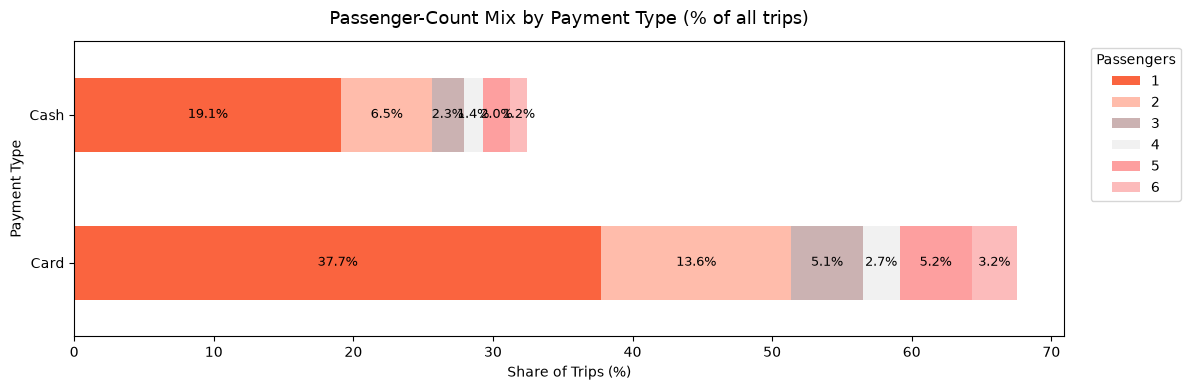

In [33]:
# Plot 3: Stacked bar - passenger mix within each payment type
fig, ax = plt.subplots(figsize=(12,4))
payment_summary.plot(x='payment_type', kind='barh', stacked=True, ax=ax, color=['#FA643F','#FFBCAB','#CBB2B2','#F1F1F1','#FD9F9F','#fcbbbb'])
ax.set_title('Passenger-Count Mix by Payment Type (% of all trips)', fontsize=13, pad=12)
ax.set_xlabel('Share of Trips (%)')
ax.set_ylabel('Payment Type')
ax.legend(title='Passengers', bbox_to_anchor=(1.02, 1), loc='upper left')
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x,y=p.get_xy()
    if width > 1:  # label only meaningful segments to avoid clutter
        ax.text(
            x + width / 2,
            y + height / 2,
            '{:.1f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9
        )
plt.tight_layout()


**How to read:** Two horizontal bars = 100% of trips split by payment. Segments = passenger sizes. Card bar is ~2× longer than Cash in every segment. Labels show % of total trips.


In [34]:
# Show the final summary table used for the plot
payment_summary.head()


,payment_type,1,2,3,4,5,6
0,Card,37.741413,13.635434,5.098276,2.652136,5.16548,3.237603
1,Cash,19.14883,6.473495,2.270659,1.362696,1.983811,1.230166


**Null Hypothesis:** There is no difference in average fare between customers who use credit cards and customers who use cash.

**Alternative Hypothesis:** There is a difference in average fare between customers who use credit cards and customers who use cash.

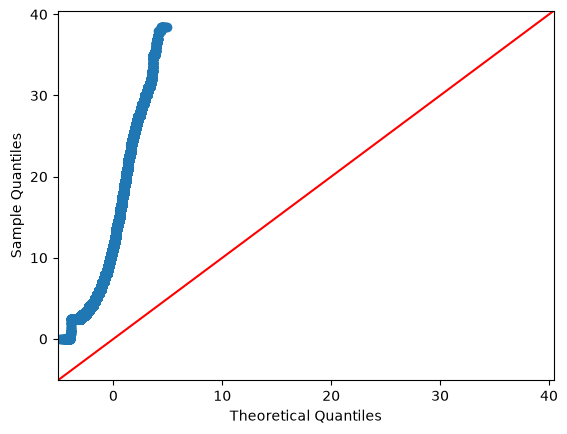

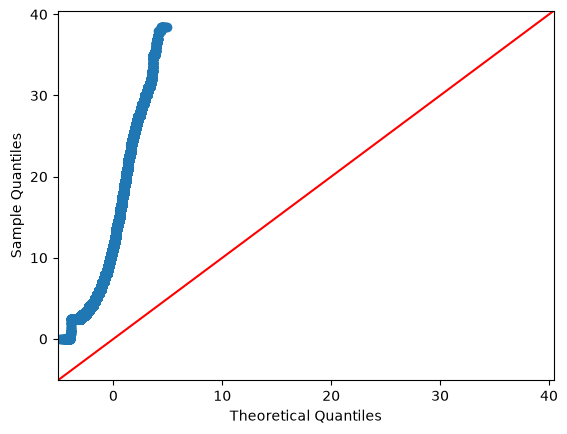

In [35]:
sm.qqplot(df['fare_amount'], line='45')

In [36]:
card_sample = df[df['payment_type']=='Card']['fare_amount']
cash_sample = df[df['payment_type']=='Cash']['fare_amount']

In [37]:
t_stats, p_value = st.ttest_ind(a = card_sample, b=cash_sample, equal_var=False)
print('T Statistic', t_stats, 'P-Value',p_value )

T Statistic 165.88209403802378 P-Value 0.0


## Conclusion & Recommendation

## Project Workflow

| Step | Description |
|---|---|
| **Descriptive Analysis** | Performed statistical analysis to summarize key aspects of the data, focusing on fare amounts and payment types. |
| **Hypothesis Testing** | Conducted a T-test to evaluate the relationship between payment type and fare amount, testing the hypothesis that different payment methods are associated with different average fare amounts. |
| **Regression Analysis** | Implemented Linear Regression to explore the relationship between trip duration (calculated from pickup and drop-off times) and fare amount. |


### Limitations (honest)
- Descriptive comparison only — **no formal t-test p-value** computed yet, and distance confounds fare (longer trips cost more regardless of payment).
- Correlation ≠ causation; tips/surcharges excluded from `fare_amount`.
